For conformity with other course deliverables and lessons, this file may be run using the CHE1147 environment [UofT-CHE1147](https://github.com/AI4ChemS/CHE1147)

```python
conda env create -f environment.yml
conda activate che1147
```

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import shap

In [2]:
pd.options.display.max_columns = 120

RANDOM_SEED = 1147
np.random.seed(1147)

# Import The EAF Dataset

In [3]:
# # Upload manually cleaning data
# from google.colab import files
# uploaded = files.upload()

In [4]:
df = pd.read_csv("preprocessed_data/design_matrix_ver_1.csv")
df = df.set_index(['HEATID', 'DATETIME'])
df.head()

,,16A,25A,25A1,26A,3A,3A (shop pipe waste),3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,B68,Briquets 6A,Coke 10-30 mm,FMN 78 GOST4755-91 class 4,FOMI,FOMI B2,FeCr025,FeSi65-4,Ferrous scrap 6A,Flux FIM,High-carbon ferrochromium,Hot briquet iron,In-house produced lime,Iron scrap,Ladle scrap,Lime,"Lime, grade 2",Liquid scrap,Magma,Magma-P,MnSi17A,Mo material briquet,Mo pellets,SIMP-RM,Scrap 3B22,Scrap B23,Scrap G/B 25A,Scrap G/B 25AS,Secondary aluminum AV 87,Separation scrap,Separation waste 3A,Shram 75,Steel scrap G/B 25A,Steelmaking iron,Vanadium alloy,Total_Scrap_Charge,Total_Scrap_Charge_Prev,25A Added,25A1 Added,3A Added,3ACh Added,AShM 75,Aluminum briquet Added,Anthracite,Artificial graphite 0.1-2.5 mm Added,B68 Added,Briquet BMK-60,CCM 03-10mm,CCM 30-60 mm,Coke 10-30 mm Added,Dolomite,FGM material,FMN 78 GOST4755-91 class 4 Added,FOMI Added,FOMI B2 Added,FeCr 850A,FeCr025 Added,FeSi 45,FeSi65-4 Added,Ferrous scrap 6A Added,Flux FIM Added,Flux FM-2-1,High-carbon ferrochromium Added,Hot briquet iron Added,In-house produced lime Added,KRS-65,KRS-65 briquets,KShU 75,Lime Added,"Lime, grade 2 Added",Liquid scrap Added,Magma Added,Magma-P Added,Magnesite brick scrap,MnSi17A Added,Mo pellets Added,Pellets AV-87,SIMP-RM Added,Scrap G/B 25A Added,Scrap G/B 25AS Added,Secondary aluminum AV 87 Added,Separation waste 3A Added,Steel scrap G/B 25A Added,Steelmaking iron Added,total_charging_time,num_baskets,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI,VALAS,VALSN,VALN,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
HEATID,DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5F0002,2015-01-01 01:31:00.000000000,0.0,0.0,0.0,0.0,105928.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17560.0,0.0,128590.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,514.0,0.0,0.0,0.0,0.0,835.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,593.0,0.0,0.0,0.0,0.0,0.0,0.0,821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1080.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1627.0,383.000000,3659.0,1160.0,1021.0,48.625
5F0003,2015-01-01 02:17:30.000000000,0.0,0.0,0.0,0.0,108033.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5473.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15320.0,0.0,128826.0,128590.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,511.0,0.0,0.0,0.0,0.0,831.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,594.0,0.0,0.0,0.0,0.0,0.0,0.0,822.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,960.0,2,0.0823,0.0172,0.0615,0.0823,0.0361,0.1913,0.0916,0.0172,0.1075,0.0053,0.0068,0.0361,1641.0,683.000000,3469.0,1117.0,957.0,48.625
5F0004,2015-01-01 03:17:30.000000000,0.0,0.0,0.0,0.0,128245.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5470.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,133715.0,128826.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1810.0,0.0,0.0,0.0,0.0,830.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,592.0,0.0,0.0,0.0,0.0,0.0,0.0,823.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1020.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1636.0,700.000000,3605.0,1204.0,789.0,47.375
5F0005,2015-01-01 04:06:00.000000000,0.0,0.0,0.0,0.0,106941.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5472.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16820.0,0.0,129233.0,133715.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,513.0,0.0,0.0,0.0,0.0,829.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,592.0,0.0,0.0,0.0,0.0,0.0,0.0,819.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1080.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1630.0,625.333333,3678.0,1191.0,812.0,49.250
5F0006,2015-01-01 04:54:24.000000000,0.0,0.0,0.0,0.0,127035.0,0.0,0.0,0.0,0.0,0.0,

In [5]:
# Remove features with perfectly 0 variance
df = df.drop(columns=df.columns[df.var(axis='rows') == 0])

# Split the dataset into those with or without steel chemistry.
# For now, remove the steel chemistry feature as it is mostly (~85%) empty.
df = df[df['VALC'].isna()]

# Drop columns that are all NaN
df = df.dropna(axis='columns', how='all')

# Drop rows that contain any NaN
df = df.dropna(axis='rows')

# Define feature and target columns
FEATURES = list(df.columns[:-1])
TARGET = 'MW'

df.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,B68,Briquets 6A,Coke 10-30 mm,FMN 78 GOST4755-91 class 4,FOMI,FOMI B2,FeSi65-4,Ferrous scrap 6A,Flux FIM,High-carbon ferrochromium,Hot briquet iron,In-house produced lime,Iron scrap,Ladle scrap,Lime,"Lime, grade 2",Liquid scrap,Magma,Magma-P,MnSi17A,Mo material briquet,Mo pellets,SIMP-RM,Scrap 3B22,Scrap B23,Scrap G/B 25A,Scrap G/B 25AS,Secondary aluminum AV 87,Separation scrap,Separation waste 3A,Shram 75,Steel scrap G/B 25A,Steelmaking iron,Vanadium alloy,Total_Scrap_Charge,Total_Scrap_Charge_Prev,25A1 Added,3A Added,3ACh Added,AShM 75,Aluminum briquet Added,Anthracite,Artificial graphite 0.1-2.5 mm Added,Briquet BMK-60,CCM 03-10mm,CCM 30-60 mm,Coke 10-30 mm Added,Dolomite,FGM material,FMN 78 GOST4755-91 class 4 Added,FOMI B2 Added,FeCr 850A,FeCr025 Added,FeSi 45,FeSi65-4 Added,Flux FIM Added,Flux FM-2-1,High-carbon ferrochromium Added,In-house produced lime Added,KRS-65,KRS-65 briquets,KShU 75,Lime Added,"Lime, grade 2 Added",Liquid scrap Added,Magma Added,Magma-P Added,Magnesite brick scrap,MnSi17A Added,Mo pellets Added,SIMP-RM Added,Scrap G/B 25A Added,Scrap G/B 25AS Added,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.00000,16911.000000,16911.000000,16911.00000,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.0,16911.0,16911.000000,16911.000000,16911.000000,16911.0,16911.000000,16911.000000,16911.0,16911.000000,16911.0,16911.000000,16911.000000,16911.000000,16911.000000,16911.00000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000
mean,5046.419135,136.103542,2292.335285,11.216368,113957.310271,1066.367157,2.877654,0.011531,7.033292,147.269824,3.815859,57.930341,278.731654,0.32535,0.065697,1.135888,0.82195,1159.586482,0.0,0.118266,434.353557,3649.017976,0.0,4.668559,599.460647,38.259949,0.0,2.481817,0.0,1.833126,0.158477,1.728461,0.191946,1.924191,0.0,474.818225,100.303235,0.639702,0.0,60.985749,0.295784,277.729880,456.906156,1.035953,130276.268937,130073.822068,0.0,15.181243,2.360830,0.147833,0.036189,0.563125,1.596594,0.404293,0.0,5.283248,1063.837739,0.0,0.0,0.032523,434.388505,0.257111,0.0,0.052983,0.716693,0.0,41.997694,0.0,399.085566,0.005913,0.867305,0.013423,308.92425,2.433623,156.998403,475.866064,9.166578,8.113476,6.309917,0.026610,0.620365,0.495535,0.312814,3.791319,0.590148,2659.102359,2.068299,1635.502847,982.395617,4292.221335,762.949441,901.256519,48.570531
std,4942.693717,904.675505,4836.046339,316.184722,25724.755668,5536.199276,154.345988,1.088153,76.715107,2408.968325,109.313827,471.033350,435.011622,42.30931,8.543374,36.175734,29.97493,2945.520759,0.0,10.874706,2038.475634,2132.622732,0.0,190.780388,1564.657995,439.287174,0.0,82.101984,0.0,44.137823,11.689293,43.726190,3.028184,144.609793,0.0,1893.369748,709.274901,9.018018,0.0,775.131590,38.464407,1722.792034,3111.309822,77.838554,24784.114169,24850.582229,0.0,955.840866,242.692077,19.224514,1.925887,24.188842,41.022482,14.594623,0.0,105.961903,593.358647,0.0,0.0,4.229393,414.238910,20.401624,0.0,4.033761,25.792826,0.0,154.164559,0.0,685.923160,0.768981,23.777

<Axes: >

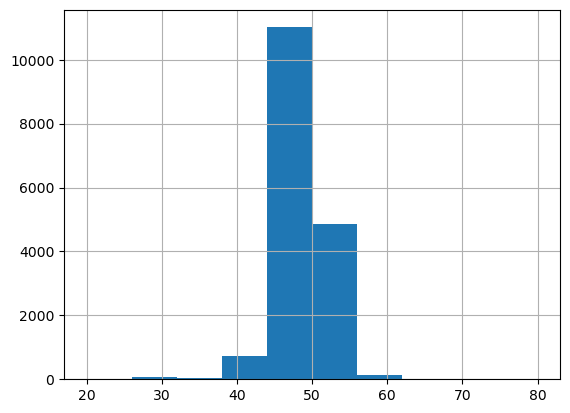

In [6]:
df['MW'].hist(range=(20,80))

In [7]:
# Qualitatively guess that any instances of "MW" being either less than 35 or more than 70 are likely false data or equipment failures.
# These energy consumption levels are thermodynamically impossible.

df = df[(df['MW']>35) & (df['MW']<70)]

In [8]:
# Train/test split
df_train, df_test = train_test_split(df, train_size=0.7, random_state=RANDOM_SEED)

df_train.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,B68,Briquets 6A,Coke 10-30 mm,FMN 78 GOST4755-91 class 4,FOMI,FOMI B2,FeSi65-4,Ferrous scrap 6A,Flux FIM,High-carbon ferrochromium,Hot briquet iron,In-house produced lime,Iron scrap,Ladle scrap,Lime,"Lime, grade 2",Liquid scrap,Magma,Magma-P,MnSi17A,Mo material briquet,Mo pellets,SIMP-RM,Scrap 3B22,Scrap B23,Scrap G/B 25A,Scrap G/B 25AS,Secondary aluminum AV 87,Separation scrap,Separation waste 3A,Shram 75,Steel scrap G/B 25A,Steelmaking iron,Vanadium alloy,Total_Scrap_Charge,Total_Scrap_Charge_Prev,25A1 Added,3A Added,3ACh Added,AShM 75,Aluminum briquet Added,Anthracite,Artificial graphite 0.1-2.5 mm Added,Briquet BMK-60,CCM 03-10mm,CCM 30-60 mm,Coke 10-30 mm Added,Dolomite,FGM material,FMN 78 GOST4755-91 class 4 Added,FOMI B2 Added,FeCr 850A,FeCr025 Added,FeSi 45,FeSi65-4 Added,Flux FIM Added,Flux FM-2-1,High-carbon ferrochromium Added,In-house produced lime Added,KRS-65,KRS-65 briquets,KShU 75,Lime Added,"Lime, grade 2 Added",Liquid scrap Added,Magma Added,Magma-P Added,Magnesite brick scrap,MnSi17A Added,Mo pellets Added,SIMP-RM Added,Scrap G/B 25A Added,Scrap G/B 25AS Added,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.0,11740.0,11740.000000,11740.000000,11740.000000,11740.0,11740.000000,11740.000000,11740.0,11740.000000,11740.0,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000
mean,5088.285094,138.233816,2317.701533,11.934412,114221.741652,1084.918739,2.697359,0.0,7.048552,148.833731,3.454855,57.126065,278.501704,0.468654,0.094634,1.113203,0.890119,1192.211499,0.0,0.085179,427.822232,3664.460307,0.0,4.586031,599.321635,38.832198,0.0,2.879046,0.0,1.959114,0.228279,1.875639,0.183901,1.884157,0.0,476.143867,99.114906,0.573850,0.0,57.063629,0.426065,291.484668,453.557922,0.980324,130678.718569,130103.756218,0.0,17.353492,3.400681,0.212947,0.044463,0.565928,1.448041,0.403407,0.0,4.953833,1067.889012,0.0,0.0,0.046848,433.953152,0.370358,0.0,0.029046,0.668654,0.0,41.020528,0.0,391.015503,0.008518,0.769250,0.009796,312.088245,2.485605,90.971039,476.473083,9.677513,8.197274,6.785264,0.038330,0.688756,0.713799,0.450596,4.340034,0.850085,2694.965928,2.071976,1635.506755,980.685334,4306.627002,764.648126,903.841738,48.806537
std,4956.167542,910.049694,4858.047436,325.461001,25285.282405,5599.122882,146.986215,0.0,77.541133,2435.131937,104.236061,462.568730,429.882433,50.779280,10.253686,36.491865,30.740635,3004.326498,0.0,9.229240,2003.159867,2136.467623,0.0,172.353880,1567.942716,441.994917,0.0,94.865992,0.0,46.106560,14.029007,45.347189,3.016297,144.486165,0.0,1895.456305,703.154859,8.699315,0.0,744.703351,46.164660,1761.167022,3083.472592,75.175779,24272.162384,24846.088585,0.0,1037.702874,291.274724,23.073101,2.157027,24.646501,39.671733,14.582381,0.0,103.430234,592.972108,0.0,0.0,5.076082,414.452685,24.485321,0.0,3.147171,26.609933,0.0,151.947908,0.0,674.307254,0.922924,22.256809,1.06

In [9]:
df_test.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,B68,Briquets 6A,Coke 10-30 mm,FMN 78 GOST4755-91 class 4,FOMI,FOMI B2,FeSi65-4,Ferrous scrap 6A,Flux FIM,High-carbon ferrochromium,Hot briquet iron,In-house produced lime,Iron scrap,Ladle scrap,Lime,"Lime, grade 2",Liquid scrap,Magma,Magma-P,MnSi17A,Mo material briquet,Mo pellets,SIMP-RM,Scrap 3B22,Scrap B23,Scrap G/B 25A,Scrap G/B 25AS,Secondary aluminum AV 87,Separation scrap,Separation waste 3A,Shram 75,Steel scrap G/B 25A,Steelmaking iron,Vanadium alloy,Total_Scrap_Charge,Total_Scrap_Charge_Prev,25A1 Added,3A Added,3ACh Added,AShM 75,Aluminum briquet Added,Anthracite,Artificial graphite 0.1-2.5 mm Added,Briquet BMK-60,CCM 03-10mm,CCM 30-60 mm,Coke 10-30 mm Added,Dolomite,FGM material,FMN 78 GOST4755-91 class 4 Added,FOMI B2 Added,FeCr 850A,FeCr025 Added,FeSi 45,FeSi65-4 Added,Flux FIM Added,Flux FM-2-1,High-carbon ferrochromium Added,In-house produced lime Added,KRS-65,KRS-65 briquets,KShU 75,Lime Added,"Lime, grade 2 Added",Liquid scrap Added,Magma Added,Magma-P Added,Magnesite brick scrap,MnSi17A Added,Mo pellets Added,SIMP-RM Added,Scrap G/B 25A Added,Scrap G/B 25AS Added,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.0,5032.0,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.0,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.0,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.000000,5032.0,5032.0,5032.0,5032.000000,5032.0,5032.0,5032.000000,5032.000000,5032.0,5032.000000,5032.0,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.00000,5032.000000,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.0,5032.0,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000
mean,4998.976351,132.095986,2229.412560,9.850954,114430.792528,1010.300079,3.377782,0.014905,7.191971,141.910175,4.763514,60.113275,282.806240,0.0,0.0,1.220191,0.685612,1081.093800,0.0,0.198728,448.326709,3643.292528,0.0,4.990064,608.101351,37.584261,0.0,1.623609,0.0,1.589825,0.0,1.432830,0.216017,2.070747,0.0,474.705087,103.272655,0.795111,0.0,71.820946,0.0,250.145072,474.280604,1.194356,130520.246423,130073.675874,0.0,10.532591,0.0,0.0,0.017886,0.572138,1.987281,0.417528,0.0,6.197734,1059.841017,0.0,0.0,0.0,439.813394,0.0,0.0,0.110294,0.848569,0.0,44.926471,0.0,408.092409,0.0,1.120032,0.022258,296.690779,1.978537,70.54849,479.282989,8.227742,7.772655,5.275835,0.0,0.469992,0.0,0.0,2.586049,0.0,2490.512719,2.075119,1635.466253,984.430006,4292.285771,763.666137,898.611288,48.762321
std,4909.569457,892.949391,4767.749116,298.093988,25668.722095,5341.927363,172.220129,1.057282,75.830553,2345.606906,121.698800,492.262217,448.474522,0.0,0.0,35.936814,28.547751,2800.355059,0.0,14.097097,2097.764914,2123.710372,0.0,230.265720,1570.743754,438.142515,0.0,40.699594,0.0,39.844863,0.0,40.349224,3.096930,146.891749,0.0,1893.762708,725.322186,9.770653,0.0,851.586493,0.0,1646.094394,3209.613615,84.723552,24708.705584,24768.258260,0.0,747.146134,0.0,0.0,1.268739,23.435511,44.539043,14.824272,0.0,113.028472,591.878600,0.0,0.0,0.0,414.263110,0.0,0.0,5.619128,24.162689,0.0,159.536334,0.0,703.866050,0.0,27.283735,1.578875,1074.745119,40.024649,1219.98492,342.355063,64.660754,76.848386,68.576289,0.0,4.896331,0.0,0.0,29.224716,0.0,8334.365249,0.354880,16.468791,714.157080,481.908771,147.559417,297.289380,2.814536
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

In [10]:
# define feature variances which will be used for feature engineering later on
feat_variance = df_train.var(axis='rows')

# Helper Functions

In [11]:
def get_regression_metrics(model, X, y_true):   # This is the same evaluation function from tutorial 04, which we can also use here.
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = np.sum(abs(y_true - y_predicted)) / len(y_true)
    mse = np.sum((y_true - y_predicted)**2) / len(y_true)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_predicted)
    maximum_error = np.max(abs(y_true - y_predicted))
    mape =  np.sum(abs((y_true - y_predicted)/y_true)) / len(y_true)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [12]:
def plot_predictions(model, X, y_true, title='Model Results'):
    '''
    Makes a scatterplot that compares y_true and y_predicted.

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    '''

    fig, ax = plt.subplots()

    ax.scatter(
        y_true,
        model.predict(X),
        alpha=0.3
    )

    ax.plot(
        [-9999, 9999],
        [-9999, 9999],
        c='k'
    )

    ax.set_ylim(np.min(y_true), np.max(y_true))
    ax.set_xlim(np.min(y_true), np.max(y_true))

    ax.set_title(title)
    ax.set_xlabel('True SEC (Mwh)')
    ax.set_ylabel('Predicted SEC (Mwh)')
    plt.show()

In [13]:
# Make a dataframe that contains all the model results

df_results_train = pd.DataFrame(columns=['mae','mse','rmse','r2','max_error','mape'])
df_results_test = pd.DataFrame(columns=['mae','mse','rmse','r2','max_error','mape'])

# Training and Evaluating Supervised Learning Models

## Baseline Model: Linear Regression (Fiona)

In [14]:
# Define the baseline model
linreg = LinearRegression()

In [15]:
# Set up a simple pipeline
linreg_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold(0)),   # Remove constant features
    ('scaling', StandardScaler()),                 # Standardize all features
    ('linreg', linreg),                            # Fit linear regression
])

In [16]:
# Fit model on training data
linreg_pipeline.fit(df_train[FEATURES], df_train[TARGET])

,steps,"[('variance_threshold', ...), ('scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06


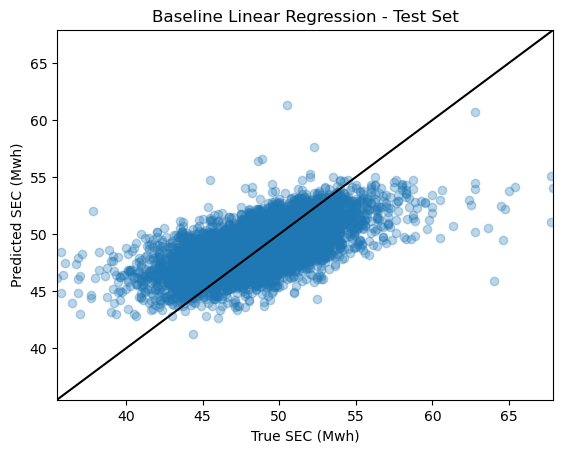

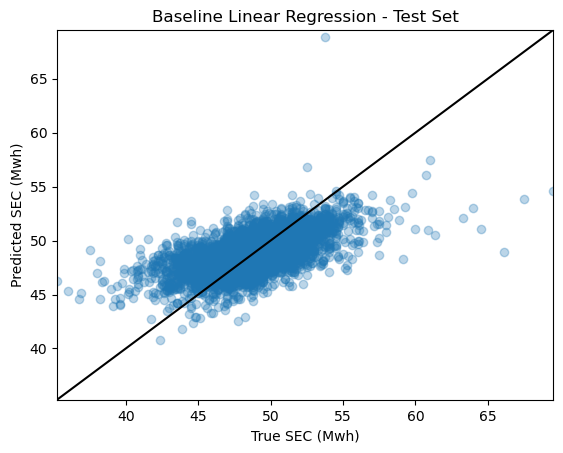

In [17]:
# Plot predictions
plot_predictions(linreg_pipeline, df_train[FEATURES], df_train[TARGET], title="Baseline Linear Regression - Test Set")
plot_predictions(linreg_pipeline, df_test[FEATURES], df_test[TARGET], title="Baseline Linear Regression - Test Set")

In [18]:
# Evaluate baseline model performance
metrics_train_linreg = get_regression_metrics(linreg_pipeline, df_train[FEATURES], df_train[TARGET])
metrics_test_linreg = get_regression_metrics(linreg_pipeline, df_test[FEATURES], df_test[TARGET])

print("Linear Regression - Train Metrics:", metrics_train_linreg)
print("Linear Regression - Test Metrics:", metrics_test_linreg)

Linear Regression - Train Metrics: {'mae': 1.65572101406287, 'mse': 4.92162744264873, 'rmse': 2.2184741248544526, 'r2': 0.36843138585283386, 'max_error': 18.120722837359224, 'mape': 0.03428482806753855}
Linear Regression - Test Metrics: {'mae': 1.6955488225791129, 'mse': 5.128593147944085, 'rmse': 2.264639739107323, 'r2': 0.3524536477515189, 'max_error': 17.184464227105515, 'mape': 0.035127000534771184}


In [19]:
# append results to dataframes

df_results_train.loc['Linear_Baseline'] = metrics_train_linreg
df_results_test.loc['Linear_Baseline'] = metrics_test_linreg

## Linear Model -- Ridge Regression Model (Kelsy)

In [20]:
# Define model
ridge = Ridge(random_state=RANDOM_SEED)

In [21]:
# Set up pipeline
ridge_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold()),   # remove low variance feature
    ('scaling', StandardScaler()),                 # standardized
    ('ridge', ridge)
])

In [22]:
# Define parameter grid
param_grid_ridge = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],    # rather than raw values, use quantile (fraction features removed based on variance)
    'scaling': [None, MinMaxScaler(), StandardScaler()],
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]  # L2 Regularization Strength
}

# Randomized search for best parameters
ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_grid_ridge,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

In [23]:
# Fit model
ridge_search.fit(df_train[FEATURES], df_train[TARGET])

,estimator,Pipeline(step...state=1147))])
,param_distributions,"{'ridge__alpha': [0.0001, 0.001, ...], 'scaling': [None, MinMaxScaler(), ...], 'variance_threshold__threshold': [0, 0.0, ...]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [24]:
# Display best model
print("Best Ridge parameters:", ridge_search.best_params_)


Best Ridge parameters: {'variance_threshold__threshold': 0, 'scaling': MinMaxScaler(), 'ridge__alpha': 1}


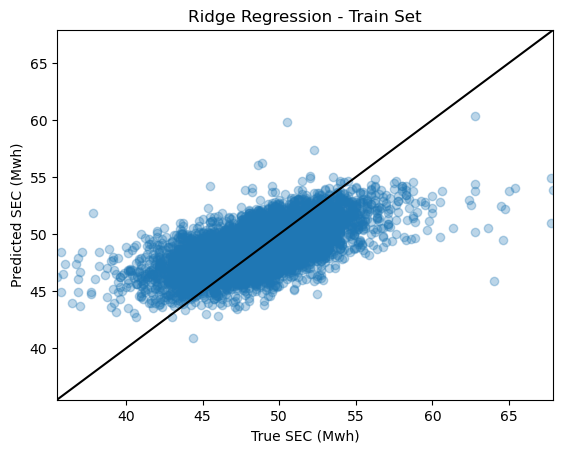

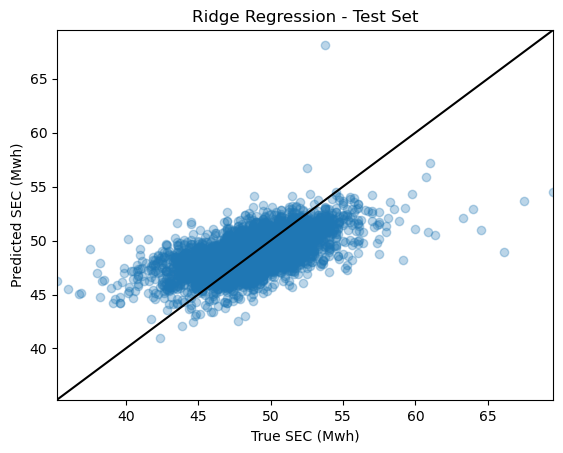

In [25]:
# Plot predictions
plot_predictions(ridge_search, df_train[FEATURES], df_train[TARGET], title="Ridge Regression - Train Set")
plot_predictions(ridge_search, df_test[FEATURES], df_test[TARGET], title="Ridge Regression - Test Set")

In [26]:
# Ridge Model Performance
metrics_train_ridge = get_regression_metrics(ridge_search, df_train[FEATURES], df_train[TARGET])
metrics_test_ridge = get_regression_metrics(ridge_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_ridge)
print("Test metrics:", metrics_test_ridge)

Train metrics: {'mae': 1.6562672743976348, 'mse': 4.92713588526974, 'rmse': 2.2197152712160495, 'r2': 0.3677245140888086, 'max_error': 18.08450567049499, 'mape': 0.034296571112264675}
Test metrics: {'mae': 1.6946360312620805, 'mse': 5.132619406891689, 'rmse': 2.2655285049832607, 'r2': 0.351945284303782, 'max_error': 17.20122976687152, 'mape': 0.03510850653770733}


In [27]:
# append results to dataframes

df_results_train.loc['Ridge'] = metrics_train_ridge
df_results_test.loc['Ridge'] = metrics_test_ridge

## Linear Model -- Lasso Regression (Kelsy)

In [28]:
# Define Model
lasso = Lasso(random_state=RANDOM_SEED)

In [29]:
# Set up pipeline
lasso_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('lasso', lasso)
])

In [30]:
# Define Parameter Grid
param_grid_lasso = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    'scaling': [None, MinMaxScaler(), StandardScaler()],
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=param_grid_lasso,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

In [31]:
# Fit Model
lasso_search.fit(df_train[FEATURES], df_train[TARGET])

,estimator,Pipeline(step...state=1147))])
,param_distributions,"{'lasso__alpha': [0.0001, 0.001, ...], 'scaling': [None, MinMaxScaler(), ...], 'variance_threshold__threshold': [0, 0.0, ...]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [32]:
# Display best model
print("Best Lasso parameters:", lasso_search.best_params_)

Best Lasso parameters: {'variance_threshold__threshold': 8.315239107186216, 'scaling': StandardScaler(), 'lasso__alpha': 0.01}


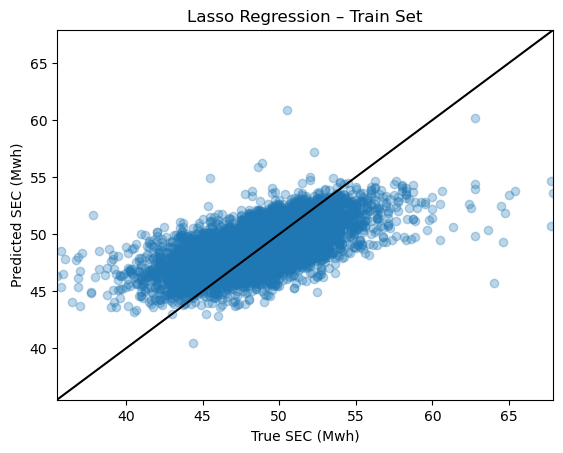

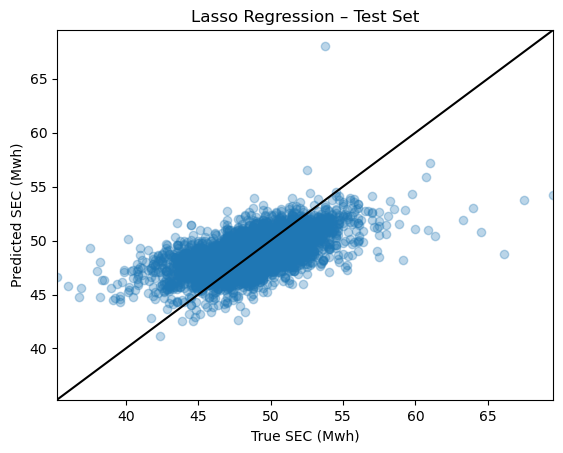

In [33]:
# Plot predictions
plot_predictions(lasso_search, df_train[FEATURES], df_train[TARGET], title="Lasso Regression – Train Set")
plot_predictions(lasso_search, df_test[FEATURES], df_test[TARGET], title="Lasso Regression – Test Set")

In [34]:
# Evaluate Lasso Performance
metrics_train_lasso = get_regression_metrics(lasso_search, df_train[FEATURES], df_train[TARGET])
metrics_test_lasso = get_regression_metrics(lasso_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_lasso)
print("Test metrics:", metrics_test_lasso)

Train metrics: {'mae': 1.6561606679801668, 'mse': 4.936859965725221, 'rmse': 2.2219045806976547, 'r2': 0.3664766699379278, 'max_error': 18.318380545549743, 'mape': 0.03430255994850531}
Test metrics: {'mae': 1.6924469230436447, 'mse': 5.129942492841532, 'rmse': 2.264937635530288, 'r2': 0.3522832767860199, 'max_error': 17.36859896277582, 'mape': 0.03506878737930917}


In [35]:
# append results to dataframes

df_results_train.loc['Lasso'] = metrics_train_lasso
df_results_test.loc['Lasso'] = metrics_test_lasso

In [36]:
lasso_search.best_estimator_.named_steps['lasso'].coef_ # Inspect how many features were used by the lasso regression based on the selected alpha value

array([ 0.        ,  0.03153928,  0.35443421, -0.005886  ,  0.        ,
       -0.08007899, -0.02715264, -0.05890096, -0.01006682,  0.04002608,
       -0.03750144,  0.67271585,  0.        ,  0.00516394, -0.00370056,
       -0.04183321,  0.04384359, -0.        ,  0.11475297,  0.        ,
       -0.        ,  0.3302405 , -0.05262444, -0.02081214, -0.07043325,
        0.00142664, -0.00998302,  0.02799673,  0.01084533,  0.18408694,
        0.00135798, -0.02840327, -0.02339518, -0.0201889 ,  0.07804832,
       -0.07412261, -0.01800547,  0.84433513, -0.58258922,  0.03971569,
       -0.        ,  0.00138474,  0.00425363, -0.        , -0.01239109,
        0.10503354,  1.13010895, -0.        , -0.16259655, -0.03227508,
       -0.        ,  0.        ,  0.0318715 , -0.03966671, -0.00791143,
        0.4055921 , -0.05675452, -0.13560146,  0.01967933, -0.01492916,
        0.03238833, -0.01432055,  0.01636378,  0.        ,  0.        ,
       -0.        ,  0.00382002, -0.00127777,  0.0537446 , -0.67

## KNN Model (Kelsy)

In [37]:
# Define model
knn = KNeighborsRegressor()

In [38]:
# Set up pipeline
knn_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold()),  # remove near and constant features
    ('scaling', StandardScaler()),
    ('knn', knn)
])

In [39]:
# Define Parameter Grid
param_grid_knn = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    'scaling': [None, MinMaxScaler(), StandardScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'knn__weights': ['uniform', 'distance'],      #equal weight + closer neighbors weigh more
    'knn__p': [1, 2]
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_grid_knn,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

In [40]:
# Train model
knn_search.fit(df_train[FEATURES], df_train[TARGET])

,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance'], 'scaling': [None, MinMaxScaler(), ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [41]:
# Display best model
print("Best KNN parameters:", knn_search.best_params_)

Best KNN parameters: {'variance_threshold__threshold': 1525.4083954909117, 'scaling': StandardScaler(), 'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 5}


c:\Users\jilai\anaconda3\envs\che1147\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


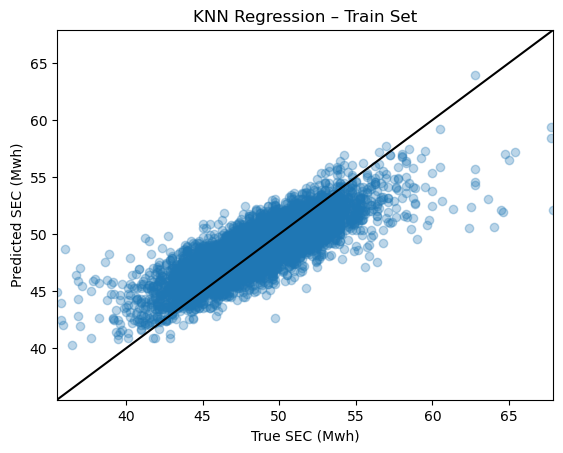

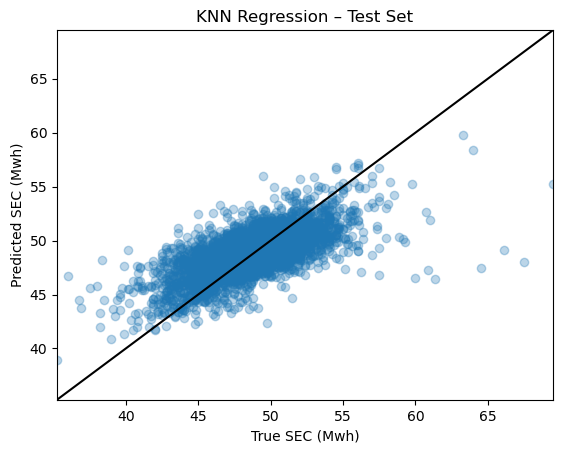

In [42]:
# Plot predictions

plot_predictions(knn_search, df_train[FEATURES], df_train[TARGET], title="KNN Regression – Train Set")
plot_predictions(knn_search, df_test[FEATURES], df_test[TARGET], title="KNN Regression – Test Set")

In [43]:
# Evaluate KNN Performance
metrics_train_knn = get_regression_metrics(knn_search, df_train[FEATURES], df_train[TARGET])
metrics_test_knn = get_regression_metrics(knn_search, df_test[FEATURES], df_test[TARGET])

print("Train metrics:", metrics_train_knn)
print("Test metrics:", metrics_test_knn)

Train metrics: {'mae': 1.1945911413969335, 'mse': 2.68724531516184, 'rmse': 1.6392819510876828, 'r2': 0.6551588231032708, 'max_error': 15.799999999999997, 'mape': 0.024653200090159748}
Test metrics: {'mae': 1.5015451112877582, 'mse': 4.266196467607314, 'rmse': 2.0654772977709808, 'r2': 0.46134156465854437, 'max_error': 19.475, 'mape': 0.030989384035549024}


In [44]:
# append results to dataframes

df_results_train.loc['KNN'] = metrics_train_knn
df_results_test.loc['KNN'] = metrics_test_knn

## Kernel Ridge Regression (RBF) Model (Fiona)

In [45]:
# Define model
krr = KernelRidge(kernel='rbf')

In [46]:
# Set up pipeline
krr_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('krr', krr)
])

In [47]:
# Define parameter grid
param_grid_krr = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    'scaling': [None, MinMaxScaler(), StandardScaler()],
    'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
    'krr__gamma': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Randomized search for best parameters
random_param_grid_krr = RandomizedSearchCV(
    krr_pipeline,
    param_distributions=param_grid_krr,
    n_iter=10,  # keep this number lower, as it tends to take a super long time for this model
    cv=5,
    verbose=2,
    n_jobs=5,
    random_state=RANDOM_SEED
)

In [48]:
# Fit model
random_param_grid_krr.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...rnel='rbf'))])
,param_distributions,"{'krr__alpha': [0.001, 0.01, ...], 'krr__gamma': [1e-05, 0.0001, ...], 'scaling': [None, MinMaxScaler(), ...], 'variance_threshold__threshold': [0, 0.0, ...]}"
,n_iter,10
,scoring,None
,n_jobs,5
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [49]:
# Display best model
print(random_param_grid_krr.best_estimator_)

Pipeline(steps=[('variance_threshold', VarianceThreshold()),
                ('scaling', MinMaxScaler()),
                ('krr', KernelRidge(alpha=0.001, gamma=0.001, kernel='rbf'))])


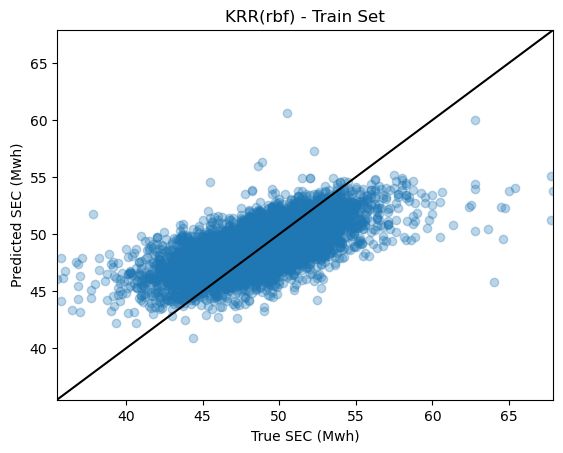

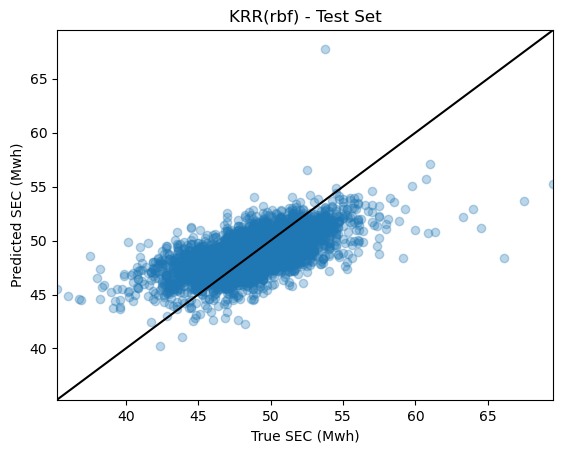

In [50]:
# Plot predictions
plot_predictions(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET], title='KRR(rbf) - Train Set')
plot_predictions(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET], title='KRR(rbf) - Test Set')

In [51]:
# Evaluate KRR-rbf performance
metrics_train_krr = get_regression_metrics(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test_krr = get_regression_metrics(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train_krr)
print("Test metrics:", metrics_test_krr)

Training metrics: {'mae': 1.60476201209346, 'mse': 4.651753590296826, 'rmse': 2.1567924309717026, 'r2': 0.4030629903191645, 'max_error': 18.20984857842268, 'mape': 0.033209000534766275}
Test metrics: {'mae': 1.6410365789344465, 'mse': 4.827830846143742, 'rmse': 2.1972325425734396, 'r2': 0.39042849305636473, 'max_error': 17.736129274300765, 'mape': 0.0339748922594182}


In [52]:
# append results to dataframes

df_results_train.loc['KRR'] = metrics_train_krr
df_results_test.loc['KRR'] = metrics_test_krr

## Random Forest Model

In [53]:
rf = RandomForestRegressor(n_jobs=5, warm_start=True, random_state=RANDOM_SEED)

In [54]:
rf_pipeline = Pipeline(
    [
        ('variance_threshold', VarianceThreshold()),
        # ('scaling', StandardScaler()),    # tree based models don't need scaling
        ('rf', rf)
    ]
)

In [55]:
# Define parameter grid for RandomizedSearchCV
param_grid_rf = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    # 'scaling': [None, MinMaxScaler(), StandardScaler()]
    'rf__n_estimators': [100, 500, 1000],
    'rf__max_depth': [10, 20, 50],
    'rf__min_samples_leaf': [4, 8, 16, 32]
}

# Randomized search for best model. Only 10 iterations as my computer is not that fast. Could do more, and refine with grid search in principle. Also reducing number of folds to try and make it faster.
random_param_grid_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_grid_rf, n_iter=10,
                        cv=5, verbose=2, n_jobs=-1, random_state=RANDOM_SEED)

In [56]:
# Fit model
random_param_grid_rf.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...start=True))])
,param_distributions,"{'rf__max_depth': [10, 20, ...], 'rf__min_samples_leaf': [4, 8, ...], 'rf__n_estimators': [100, 500, ...], 'variance_threshold__threshold': [0, 0.0, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [57]:
# Display the best model
print(random_param_grid_rf.best_estimator_)

Pipeline(steps=[('variance_threshold', VarianceThreshold()),
                ('rf',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=4,
                                       n_estimators=1000, n_jobs=5,
                                       random_state=1147, warm_start=True))])


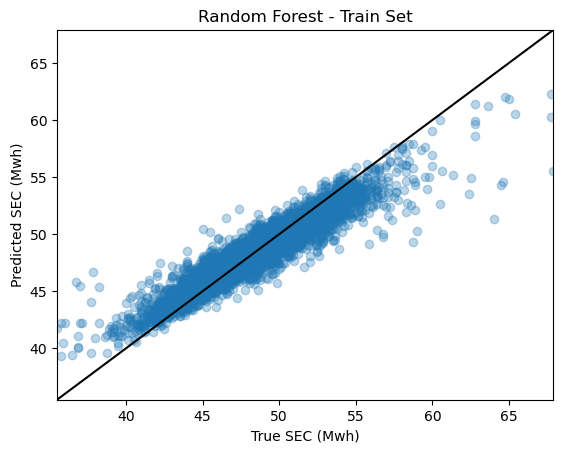

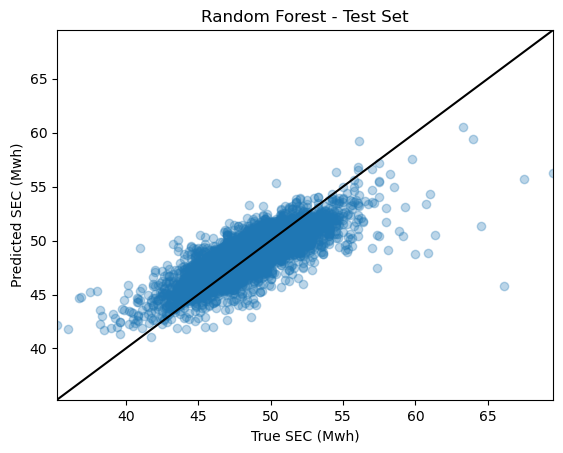

In [58]:
# Plot predictions
plot_predictions(random_param_grid_rf.best_estimator_, df_train[FEATURES], df_train[TARGET], title="Random Forest - Train Set")
plot_predictions(random_param_grid_rf.best_estimator_, df_test[FEATURES], df_test[TARGET], title="Random Forest - Test Set")

In [59]:
# Evaluate Random Forest performance
metrics_train_rf = get_regression_metrics(random_param_grid_rf.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test_rf = get_regression_metrics(random_param_grid_rf.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train_rf)
print("Test metrics:", metrics_test_rf)

Training metrics: {'mae': 0.6979324721527617, 'mse': 1.0414284621749301, 'rmse': 1.0205040235956593, 'r2': 0.8663585291138464, 'max_error': 12.64463994139031, 'mape': 0.014328856618895795}
Test metrics: {'mae': 1.2496115072955627, 'mse': 2.9552620706335144, 'rmse': 1.7190875692161567, 'r2': 0.6268627441145017, 'max_error': 20.294661140758755, 'mape': 0.025675376141679834}


In [60]:
# append results to dataframes

df_results_train.loc['RF'] = metrics_train_rf
df_results_test.loc['RF'] = metrics_test_rf

## Gradient Boosting Model

In [61]:
# Define model
gb = GradientBoostingRegressor(warm_start=True, random_state=RANDOM_SEED)

In [62]:
# Set up pipeline
gb_pipeline = Pipeline(
    [
        ('variance_threshold', VarianceThreshold()),
        # ('scaling', StandardScaler()),
        ('gb', gb)
    ]
)

In [63]:
# Define parameter grid for RandomizedSearchCV
param_grid_gb = {
    'variance_threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    'gb__n_estimators': [100, 500, 1000],
    'gb__learning_rate': [0.01, 0.1, 0.2, 0.5],
    'gb__max_depth': [3, 4, 5, 6],
    'gb__min_samples_leaf': [1, 3, 5, 10],
    'gb__max_features': ['sqrt', 'log2', None],
    'gb__loss': ['squared_error', 'absolute_error'],
}

# Randomized search for best model
random_param_grid_gb = RandomizedSearchCV(gb_pipeline, param_distributions=param_grid_gb, n_iter=10,
                        cv=5, verbose=2, n_jobs=-1, random_state=RANDOM_SEED)

In [64]:
# Fit model
random_param_grid_gb.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...start=True))])
,param_distributions,"{'gb__learning_rate': [0.01, 0.1, ...], 'gb__loss': ['squared_error', 'absolute_error'], 'gb__max_depth': [3, 4, ...], 'gb__max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,1147
,error_score,nan


In [65]:
# Display the best model
print(random_param_grid_gb.best_estimator_)

Pipeline(steps=[('variance_threshold',
                 VarianceThreshold(threshold=1525.4083954909117)),
                ('gb',
                 GradientBoostingRegressor(max_depth=6, max_features='log2',
                                           min_samples_leaf=3,
                                           n_estimators=1000, random_state=1147,
                                           warm_start=True))])


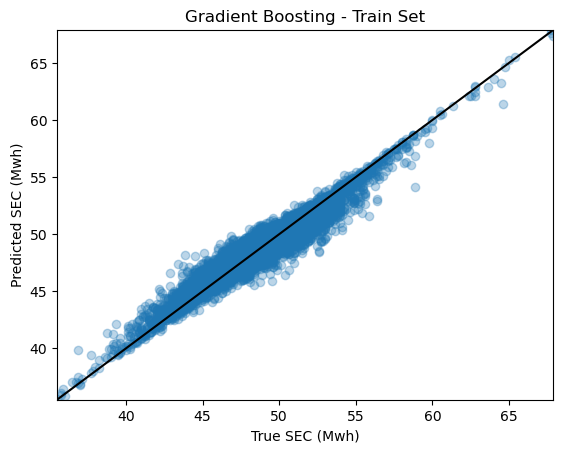

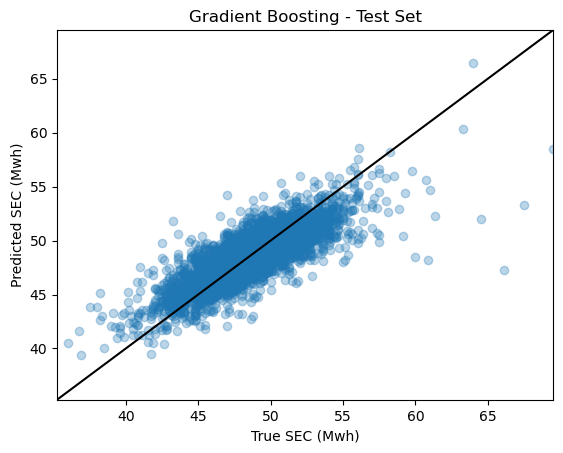

In [66]:
# Plot predictions
plot_predictions(random_param_grid_gb.best_estimator_, df_train[FEATURES], df_train[TARGET], title="Gradient Boosting - Train Set")
plot_predictions(random_param_grid_gb.best_estimator_, df_test[FEATURES], df_test[TARGET], title="Gradient Boosting - Test Set")

In [67]:
# Evaluate Random Forest performance
metrics_train_gb = get_regression_metrics(random_param_grid_gb.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test_gb = get_regression_metrics(random_param_grid_gb.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train_gb)
print("Test metrics:", metrics_test_gb)

Training metrics: {'mae': 0.5626202482902707, 'mse': 0.5897026811192215, 'rmse': 0.7679210122917731, 'r2': 0.924326310877181, 'max_error': 4.700990455009716, 'mape': 0.011554998530425744}
Test metrics: {'mae': 1.2543379509787607, 'mse': 2.8835183163338103, 'rmse': 1.6980925523462524, 'r2': 0.6359212529595655, 'max_error': 18.80922031972122, 'mape': 0.02574167290641274}


In [68]:
# append results to dataframes

df_results_train.loc['GB'] = metrics_train_gb
df_results_test.loc['GB'] = metrics_test_gb

## Summary Table of Model Results

In [69]:
df_results_test

,mae,mse,rmse,r2,max_error,mape
Linear_Baseline,1.695549,5.128593,2.264640,0.352454,17.184464,0.035127
Ridge,1.694636,5.132619,2.265529,0.351945,17.201230,0.035109
Lasso,1.692447,5.129942,2.264938,0.352283,17.368599,0.035069
KNN,1.501545,4.266196,2.065477,0.461342,19.475000,0.030989
KRR,1.641037,4.827831,2.197233,0.390428,17.736129,0.033975
RF,1.249612,2.955262,1.719088,0.626863,20.294661,0.025675
GB,1.254338,2.883518,1.698093,0.635921,18.809220,0.025742


In [70]:
# df_results_test.to_clipboard()

# Interpretation of Best Model

In [71]:
# since shap cannot take a pipeline directly, I will separate out the steps to isolate the actual gradient boosting estimator.

df_train_gb = df_train.loc[:, df_train.var() > random_param_grid_gb.best_estimator_.named_steps['variance_threshold'].threshold]
# VarianceThreshold(threshold=random_param_grid_gb.best_estimator_.named_steps['variance threshold'].threshold).fit_transform(df_train) # data input to the estimatoe
gb_model = random_param_grid_gb.best_estimator_.named_steps['gb']  # gb estimator

In [72]:
# define the shap explainer
GB_explainer = shap.TreeExplainer(gb_model)

# get shap values for training set
shap_values = GB_explainer(df_train_gb)

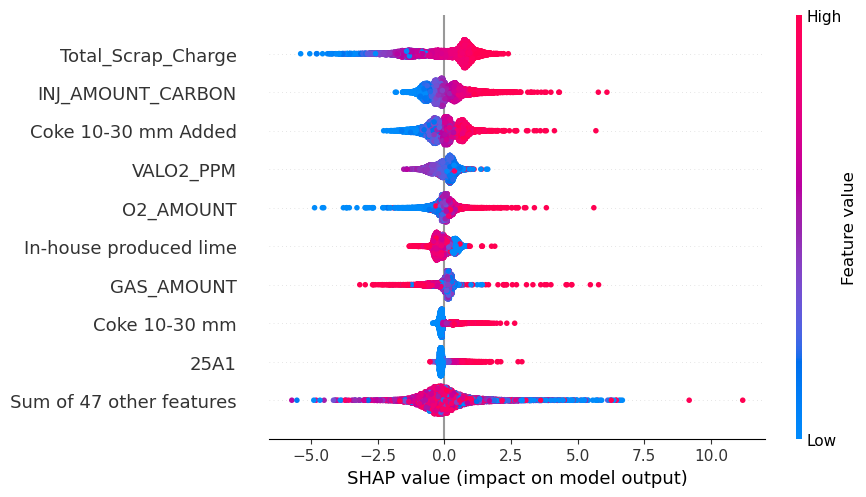

In [73]:
shap.plots.beeswarm(shap_values)